# Introduction

**Data Loading**

**Data Cleaning**

**Correlation Analysis**

**Covariance**

In [4]:
%pip install darts


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np

print(help(np.corrcoef))

Help on _ArrayFunctionDispatcher in module numpy:

corrcoef(x, y=None, rowvar=True, bias=<no value>, ddof=<no value>, *, dtype=None)
    Return Pearson product-moment correlation coefficients.
    
    Please refer to the documentation for `cov` for more detail.  The
    relationship between the correlation coefficient matrix, `R`, and the
    covariance matrix, `C`, is
    
    .. math:: R_{ij} = \frac{ C_{ij} } { \sqrt{ C_{ii} C_{jj} } }
    
    The values of `R` are between -1 and 1, inclusive.
    
    Parameters
    ----------
    x : array_like
        A 1-D or 2-D array containing multiple variables and observations.
        Each row of `x` represents a variable, and each column a single
        observation of all those variables. Also see `rowvar` below.
    y : array_like, optional
        An additional set of variables and observations. `y` has the same
        shape as `x`.
    rowvar : bool, optional
        If `rowvar` is True (default), then each row represents a
       

In [2]:
import pandas as pd

file_path = "../Data/dropout_clean_new.csv"

df = pd.read_csv(file_path)
print(df[0:5])

     Student ID  Dropout (1=Yes 0=No)   Degree Code  Study Mode  Entry Year  \
0  0002ccc8623e                     0  ec2e990b934d           1      2021.0   
1  00075bbc7af3                     0  bb668ca95563           1      2022.0   
2  0008337bd791                     0  1d0ebea552eb           1      2020.0   
3  000be0ddb26c                     0  d6a403173361           1      2022.0   
4  000d5aac651d                     0  0fecf9247f3d           1      2019.0   

  Admission Type  Active Enrollment  Displaced Student Second Degree Student  \
0            BMA                  1                  1                   NaN   
1            NCA                  1                  0                   1,0   
2            NAP                  1                  0                   NaN   
3            NAP                  1                  1                   NaN   
4            NAP                  1                  1                   NaN   

   Overall Pass Rate (%)  ...  Platform Even

**Is each index unique**

In [33]:
df.index.is_unique


True

In [32]:
df_cleaned = pd.DataFrame.dropna(df)

print(df_cleaned)

Empty DataFrame
Columns: [Student ID, Dropout (1=Yes 0=No), Status (A=Dropout B=Stayed), Degree Code, Study Mode, Entry Year, Admission Type, Active Enrollment, Displaced Student, Second Degree Student, Overall Pass Rate (%), Pass Rate Semester A (%), Pass Rate Semester B (%), Pass Rate Last Year (%), Pass Rate 2 Years Ago (%), Credits Enrolled Total, Credits Passed Total, Credits Passed Normal, Credits Passed Sem A, Credits Passed Sem B, Credits Pending Grade, Lowest Year of Study, Highest Year of Study, Unpaid Fees Flag, Platform Days Logged (Total), Platform Events (Total), Platform Minutes (Total), Platform Visits (Total), Campus WiFi Days (Total), Resource Access Days (Total), Assignment Submissions (Total), Test Submissions (Total), Performance Bucket, Engagement Level, Credits Enrolled Band]
Index: []

[0 rows x 35 columns]


**Drop studentid column**

In [51]:
label = "Student ID"
df_without_studentid = df.drop(columns=label)
print(df_without_studentid)

       Dropout (1=Yes 0=No) Status (A=Dropout B=Stayed)   Degree Code  \
0                         0                      Stayed  ec2e990b934d   
1                         0                      Stayed  bb668ca95563   
2                         0                      Stayed  1d0ebea552eb   
3                         0                      Stayed  d6a403173361   
4                         0                      Stayed  0fecf9247f3d   
...                     ...                         ...           ...   
20422                     0                      Stayed  5ec1a0c99d42   
20423                     1                     Dropout  01d54579da44   
20424                     0                      Stayed  2c7d5490e605   
20425                     0                      Stayed  7559ca4a957c   
20426                     0                      Stayed  38b2d03f3256   

      Study Mode  Entry Year Admission Type  Active Enrollment  \
0      Full-time      2021.0            BMA              

In [ ]:
label1 = ["Degree Code","Second Degree Student","Performance Bucket","Engagement Level","Credits Enrolled Band","Displaced Student","Study Mode","Admission Type","Pass Rate Semester B (%)","Pass Rate Last Year (%)","Pass Rate 2 Years Ago (%)"]
df_all_ints = df_without_studentid.drop(columns=label1)
print(df_all_ints)

       Dropout (1=Yes 0=No)  Entry Year  Active Enrollment  \
0                         0      2021.0                1.0   
1                         0      2022.0                1.0   
2                         0      2020.0                1.0   
3                         0      2022.0                1.0   
4                         0      2019.0                1.0   
...                     ...         ...                ...   
20422                     0         NaN                0.0   
20423                     1      2022.0                0.0   
20424                     0      2019.0                0.0   
20425                     0      2021.0                1.0   
20426                     0      2020.0                1.0   

       Overall Pass Rate (%)  Pass Rate Semester A (%)  \
0                     100.00                    100.00   
1                       0.00                      0.00   
2                      80.43                     86.96   
3                      

**Correlation Matrix**

In [ ]:
df_all_ints = df_all_ints.replace(",", ".", regex=True)
df_all_ints = df_all_ints.apply(pd.to_numeric)

In [81]:
print(df_all_ints)

       Dropout (1=Yes 0=No)  Entry Year  Active Enrollment  \
0                         0      2021.0                1.0   
1                         0      2022.0                1.0   
2                         0      2020.0                1.0   
3                         0      2022.0                1.0   
4                         0      2019.0                1.0   
...                     ...         ...                ...   
20422                     0         NaN                0.0   
20423                     1      2022.0                0.0   
20424                     0      2019.0                0.0   
20425                     0      2021.0                1.0   
20426                     0      2020.0                1.0   

       Overall Pass Rate (%)  Pass Rate Semester A (%)  \
0                     100.00                    100.00   
1                       0.00                      0.00   
2                      80.43                     86.96   
3                      

In [83]:
corr_matrix = df_all_ints.corr() 

print(corr_matrix)


                                Dropout (1=Yes 0=No)  Entry Year  \
Dropout (1=Yes 0=No)                        1.000000    0.031911   
Entry Year                                  0.031911    1.000000   
Active Enrollment                          -0.346569    0.300293   
Overall Pass Rate (%)                      -0.331713    0.230680   
Pass Rate Semester A (%)                   -0.205245    0.098113   
Credits Enrolled Total                     -0.123311    0.498196   
Credits Passed Total                       -0.230987    0.427099   
Credits Passed Normal                      -0.235223    0.383813   
Credits Passed Sem A                       -0.159786    0.182512   
Credits Passed Sem B                       -0.191758    0.284262   
Credits Pending Grade                       0.113014   -0.014820   
Lowest Year of Study                       -0.091696   -0.701851   
Highest Year of Study                      -0.101659   -0.783146   
Unpaid Fees Flag                                

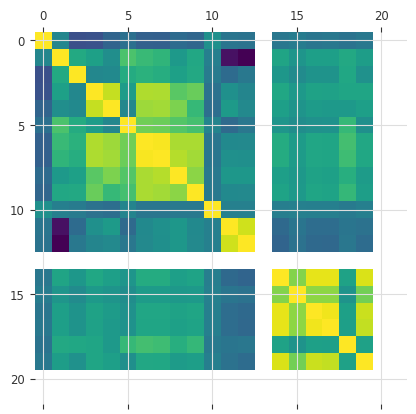

In [85]:
import matplotlib.pyplot as plt

plt.matshow(corr_matrix)
plt.show()

**Better Visualization**

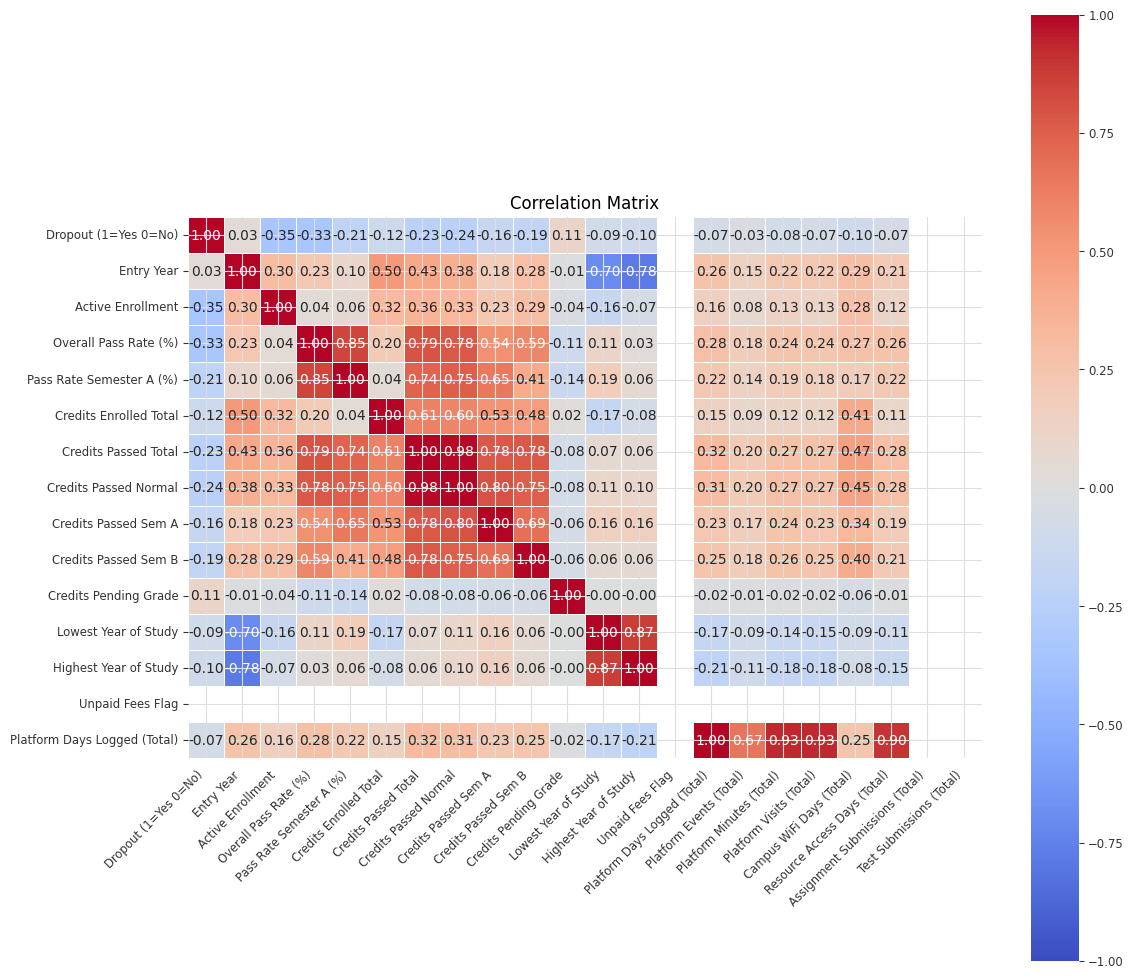

In [89]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix[0:15],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()